# Módulo 01: Problema de Transporte con Capacidad Limitada

**Evaluación Técnica: Proceso de Selección**

| Parámetro | Valor |
|-----------|-------|
| Almacenes | 5 |
| Puntos de demanda | 20 |
| Capacidades | [500 – 2000 uds] |
| Demandas | [50 – 300 uds] |
| Solver | OR-Tools (GLOP) |
| Seed | 42 |

##Celda 1: Instalación de dependencias

> Ejecutar primero la siguiente celda.

In [12]:
!pip install ortools matplotlib pandas numpy networkx -q
print('Dependencias instaladas')

Dependencias instaladas


## Celda 2: Imports y Paleta Ternium

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams
from ortools.linear_solver import pywraplp

SEED = 42

# ── Paleta de colores Ternium ──────────────────
TERNIUM = {
    'orange':     '#F5A800',
    'red':        '#E3000F',
    'black':      '#1A1A1A',
    'gray':       '#6B6B6B',
    'light_gray': '#D6D6D6',
    'dark_gray':  '#3D3D3D',
    'bg':         '#FFFFFF',
    'grid':       '#EEEEEE',
}
PALETTE = ['#F5A800', '#E3000F', '#3D3D3D', '#6B6B6B', '#D6D6D6']

def _base_style(ax, fig):
    ax.set_facecolor(TERNIUM['bg'])
    fig.patch.set_facecolor(TERNIUM['bg'])
    ax.grid(color=TERNIUM['grid'], linewidth=0.7, linestyle='--', zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(TERNIUM['light_gray'])
    ax.spines['bottom'].set_color(TERNIUM['light_gray'])
    ax.tick_params(colors=TERNIUM['gray'], labelsize=9)
    ax.xaxis.label.set_color(TERNIUM['dark_gray'])
    ax.yaxis.label.set_color(TERNIUM['dark_gray'])

print('Imports y Paleta Ternium cargados')

Imports y Paleta Ternium cargados


## 1. Generación de Datos Sintéticos

Costos proporcionales a distancia euclidiana + ruido. Seed fijo para reproducibilidad.

In [14]:
def generate_data(seed=SEED):
    rng = np.random.default_rng(seed)
    n_warehouses    = 5
    n_demand_points = 20

    warehouse_coords = rng.uniform(0, 100, size=(n_warehouses, 2))
    demand_coords    = rng.uniform(0, 100, size=(n_demand_points, 2))

    costs = np.zeros((n_warehouses, n_demand_points))
    for i in range(n_warehouses):
        for j in range(n_demand_points):
            dist = np.linalg.norm(warehouse_coords[i] - demand_coords[j])
            noise = rng.uniform(0.8, 1.2)
            costs[i, j] = round(dist * noise, 2)

    capacities = rng.integers(500, 2001, size=n_warehouses)
    demands    = rng.integers(50, 301,  size=n_demand_points)

    print(f'Oferta total : {capacities.sum()} uds')
    print(f'Demanda total: {demands.sum()} uds')

    return {
        'n_warehouses':     n_warehouses,
        'n_demand_points':  n_demand_points,
        'costs':            costs,
        'capacities':       capacities,
        'demands':          demands,
        'warehouse_coords': warehouse_coords,
        'demand_coords':    demand_coords,
        'warehouse_names':  [f'Almacén {i+1}' for i in range(n_warehouses)],
        'demand_names':     [f'Punto {j+1}'   for j in range(n_demand_points)],
    }

data = generate_data()

print('\n--- Capacidades ---')
display(pd.DataFrame({'Almacén': data['warehouse_names'], 'Capacidad (uds)': data['capacities']}))
print('\n--- Demandas ---')
display(pd.DataFrame({'Punto': data['demand_names'], 'Demanda (uds)': data['demands']}))

Oferta total : 6458 uds
Demanda total: 3541 uds

--- Capacidades ---


,Almacén,Capacidad (uds)
0,Almacén 1,1045
1,Almacén 2,1740
2,Almacén 3,514
3,Almacén 4,1845
4,Almacén 5,1314



--- Demandas ---


,Punto,Demanda (uds)
0,Punto 1,85
1,Punto 2,125
2,Punto 3,189
3,Punto 4,129
4,Punto 5,77
5,Punto 6,217
6,Punto 7,218
7,Punto 8,79
8,Punto 9,120
9,Punto 10,111


## 2. Formulación y Resolución del Modelo

$$\min \sum_{i=1}^{5} \sum_{j=1}^{20} c_{ij} \cdot x_{ij}$$

**Restricciones:**
- Capacidad: $\sum_{j} x_{ij} \leq cap_i \quad \forall i$
- Demanda: $\sum_{i} x_{ij} \geq d_j \quad \forall j$
- No negatividad: $x_{ij} \geq 0$

In [15]:
def solve_transport(data, demand_scale=1.0):
    costs      = data['costs']
    capacities = data['capacities']
    demands    = (data['demands'] * demand_scale).astype(int)
    I = data['n_warehouses']
    J = data['n_demand_points']

    solver = pywraplp.Solver.CreateSolver('GLOP')
    solver.SetTimeLimit(60_000)

    x = {}
    for i in range(I):
        for j in range(J):
            x[i, j] = solver.NumVar(0.0, solver.infinity(), f'x_{i}_{j}')

    objective = solver.Objective()
    for i in range(I):
        for j in range(J):
            objective.SetCoefficient(x[i, j], costs[i, j])
    objective.SetMinimization()

    for i in range(I):
        ct = solver.Constraint(0, float(capacities[i]), f'cap_{i}')
        for j in range(J):
            ct.SetCoefficient(x[i, j], 1)

    for j in range(J):
        ct = solver.Constraint(float(demands[j]), solver.infinity(), f'dem_{j}')
        for i in range(I):
            ct.SetCoefficient(x[i, j], 1)

    status = solver.Solve()
    status_map = {
        pywraplp.Solver.OPTIMAL:    'ÓPTIMO',
        pywraplp.Solver.FEASIBLE:   'FACTIBLE',
        pywraplp.Solver.INFEASIBLE: 'INFACTIBLE',
    }
    status_str = status_map.get(status, 'DESCONOCIDO')

    flows = np.zeros((I, J))
    total_cost = None
    if status in (pywraplp.Solver.OPTIMAL, pywraplp.Solver.FEASIBLE):
        total_cost = solver.Objective().Value()
        for i in range(I):
            for j in range(J):
                flows[i, j] = x[i, j].solution_value()

    print(f'Escala: {demand_scale:.0%} | Estado: {status_str} | Costo: {total_cost:,.2f}')
    return {'status': status_str, 'total_cost': total_cost, 'flows': flows, 'demands': demands, 'data': data}

result_base = solve_transport(data, demand_scale=1.0)

df_flows = pd.DataFrame(
    result_base['flows'],
    index=data['warehouse_names'],
    columns=data['demand_names']
).round(1)
print('\n--- Flujos óptimos (unidades enviadas) ---')
display(df_flows)

Escala: 100% | Estado: ÓPTIMO | Costo: 83,980.46

--- Flujos óptimos (unidades enviadas) ---


,Punto 1,Punto 2,Punto 3,Punto 4,Punto 5,Punto 6,Punto 7,Punto 8,Punto 9,Punto 10,Punto 11,Punto 12,Punto 13,Punto 14,Punto 15,Punto 16,Punto 17,Punto 18,Punto 19,Punto 20
Almacén 1,0.0,0.0,0.0,129.0,0.0,217.0,0.0,79.0,120.0,0.0,0.0,0.0,129.0,0.0,0.0,0.0,77.0,0.0,0.0,294.0
Almacén 2,0.0,0.0,0.0,0.0,77.0,0.0,218.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Almacén 3,85.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0,0.0,0.0,0.0,0.0,0.0
Almacén 4,0.0,125.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,215.0,0.0,103.0,0.0,0.0,130.0,0.0,204.0,0.0,0.0
Almacén 5,0.0,0.0,189.0,0.0,0.0,0.0,0.0,0.0,0.0,111.0,0.0,233.0,0.0,285.0,217.0,0.0,0.0,0.0,279.0,0.0


## 3. Mapa de Flujos

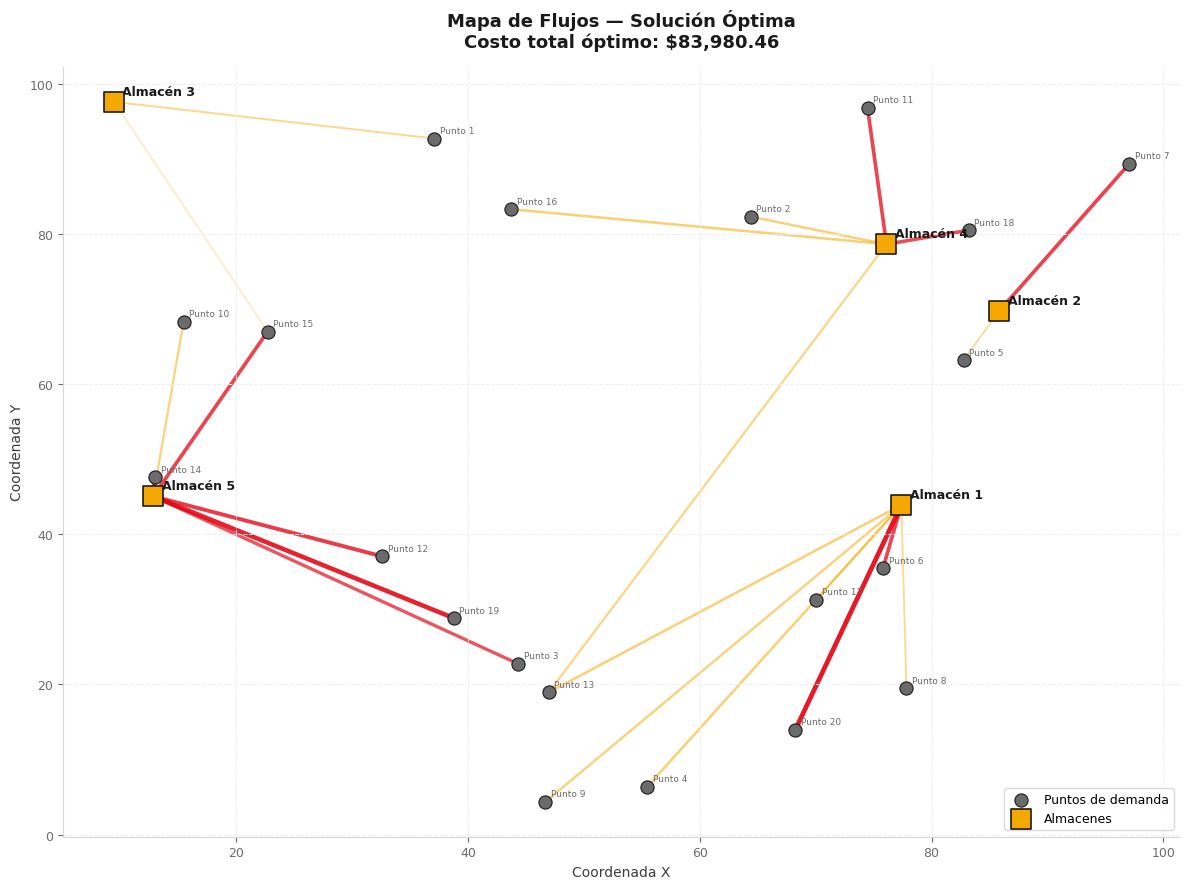

Guardado: flow_map.png


In [16]:
def plot_flow_map(result, title='Mapa de Flujos — Solución Óptima'):
    data     = result['data']
    flows    = result['flows']
    w_coords = data['warehouse_coords']
    d_coords = data['demand_coords']
    max_flow = flows.max() if flows.max() > 0 else 1

    fig, ax = plt.subplots(figsize=(12, 9))
    _base_style(ax, fig)

    for i in range(data['n_warehouses']):
        for j in range(data['n_demand_points']):
            if flows[i, j] > 0.1:
                ratio = flows[i, j] / max_flow
                alpha = 0.25 + 0.65 * ratio
                lw    = 0.6 + 2.8 * ratio
                color = TERNIUM['orange'] if ratio < 0.5 else TERNIUM['red']
                ax.plot([w_coords[i,0], d_coords[j,0]], [w_coords[i,1], d_coords[j,1]],
                        color=color, alpha=alpha, linewidth=lw, zorder=1)

    ax.scatter(d_coords[:,0], d_coords[:,1], c=TERNIUM['gray'], s=90, zorder=3,
               label='Puntos de demanda', edgecolors=TERNIUM['black'], linewidths=0.8)
    for j, name in enumerate(data['demand_names']):
        ax.annotate(name, d_coords[j], fontsize=6.5, color=TERNIUM['gray'],
                    xytext=(4,4), textcoords='offset points')

    ax.scatter(w_coords[:,0], w_coords[:,1], c=TERNIUM['orange'], s=220, marker='s', zorder=4,
               label='Almacenes', edgecolors=TERNIUM['black'], linewidths=1.2)
    for i, name in enumerate(data['warehouse_names']):
        ax.annotate(name, w_coords[i], fontsize=9, color=TERNIUM['black'],
                    fontweight='bold', xytext=(6,5), textcoords='offset points')

    ax.set_title(f"{title}\nCosto total óptimo: ${result['total_cost']:,.2f}",
                 color=TERNIUM['black'], fontsize=13, fontweight='bold', pad=14)
    ax.set_xlabel('Coordenada X', fontsize=10)
    ax.set_ylabel('Coordenada Y', fontsize=10)
    legend = ax.legend(loc='lower right', framealpha=0.9, fontsize=9, edgecolor=TERNIUM['light_gray'])
    legend.get_frame().set_facecolor(TERNIUM['bg'])
    plt.tight_layout()
    plt.savefig('flow_map.png', dpi=150, bbox_inches='tight', facecolor=TERNIUM['bg'])
    plt.show()
    print('Guardado: flow_map.png')

plot_flow_map(result_base)

#En este mapa las coordenadas son simuladas, no son coordenadas geográficas reales.

¿Para qué sirven entonces?

Solo para calcular los costos de transporte de forma realista:
- pythondist = np.linalg.norm(warehouse_coords[i] - demand_coords[j])

Aquí np.linalg.norm calcula la distancia euclidiana entre dos puntos, entre más lejos estén en el plano, más caro es transportar. Eso hace que el modelo tenga sentido lógico aunque los datos sean sintéticos.

## 4. Distribución de Costos por Almacén


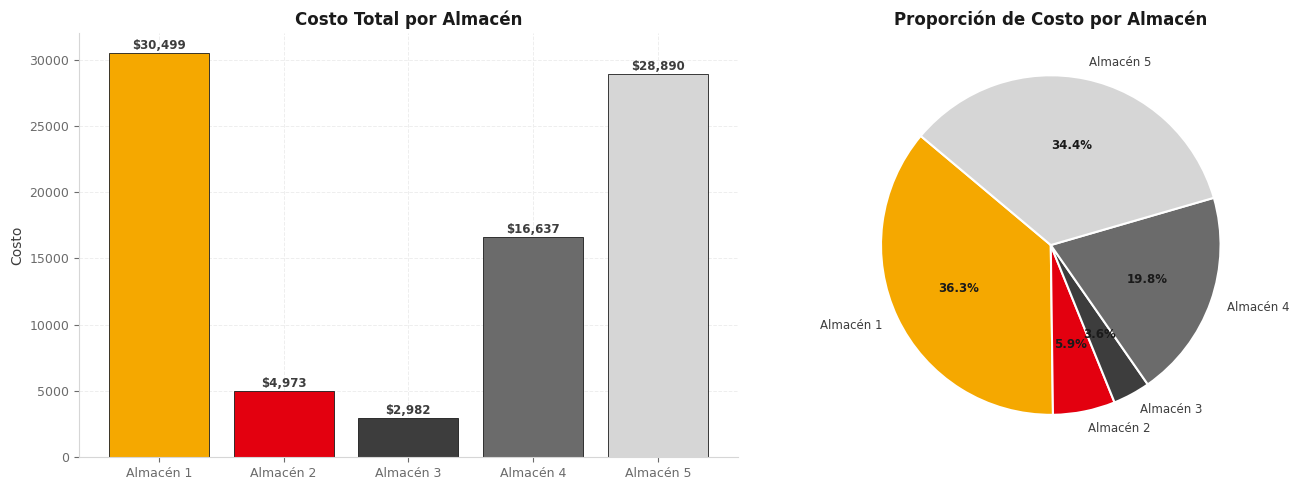

Guardado: cost_distribution.png


In [17]:
def plot_cost_distribution(result):
    data  = result['data']
    flows = result['flows']
    costs = data['costs']
    cost_by_wh = [(flows[i] * costs[i]).sum() for i in range(data['n_warehouses'])]
    names = data['warehouse_names']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor(TERNIUM['bg'])

    ax1 = axes[0]
    _base_style(ax1, fig)
    bars = ax1.bar(names, cost_by_wh, color=PALETTE, edgecolor=TERNIUM['black'], linewidth=0.6, zorder=2)
    ax1.set_title('Costo Total por Almacén', color=TERNIUM['black'], fontsize=12, fontweight='bold')
    ax1.set_ylabel('Costo', fontsize=10)
    for bar, val in zip(bars, cost_by_wh):
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max(cost_by_wh) * 0.01,
                 f'${val:,.0f}', ha='center', color=TERNIUM['dark_gray'], fontsize=8.5, fontweight='bold')

    ax2 = axes[1]
    ax2.set_facecolor(TERNIUM['bg'])
    wedges, texts, autotexts = ax2.pie(
        cost_by_wh, labels=names, colors=PALETTE,
        autopct='%1.1f%%', startangle=140,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
        textprops={'color': TERNIUM['dark_gray'], 'fontsize': 8.5}
    )
    for at in autotexts:
        at.set_color(TERNIUM['black'])
        at.set_fontweight('bold')
    ax2.set_title('Proporción de Costo por Almacén', color=TERNIUM['black'], fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig('cost_distribution.png', dpi=150, bbox_inches='tight', facecolor=TERNIUM['bg'])
    plt.show()
    print('Guardado: cost_distribution.png')

plot_cost_distribution(result_base)

## 5️⃣ Análisis de Sensibilidad: ¿Qué pasa si la demanda crece?

In [18]:
def sensitivity_analysis(data, scales=[1.0, 1.1, 1.2, 1.3]):
    records = []
    for s in scales:
        r = solve_transport(data, demand_scale=s)
        records.append({
            'Escala demanda': f'{s:.0%}',
            'Demanda total':  int(r['demands'].sum()),
            'Costo óptimo':  round(r['total_cost'], 2) if r['total_cost'] else None,
            'Estado':         r['status'],
        })
    df = pd.DataFrame(records)
    base = df.loc[df['Escala demanda'] == '100%', 'Costo óptimo'].values[0]
    df['Δ costo vs base (%)'] = df['Costo óptimo'].apply(
        lambda c: round((c - base) / base * 100, 2) if c else None
    )
    return df

df_sensitivity = sensitivity_analysis(data)
display(df_sensitivity)

Escala: 100% | Estado: ÓPTIMO | Costo: 83,980.46
Escala: 110% | Estado: ÓPTIMO | Costo: 95,360.28
Escala: 120% | Estado: ÓPTIMO | Costo: 107,164.07
Escala: 130% | Estado: ÓPTIMO | Costo: 119,366.95


,Escala demanda,Demanda total,Costo óptimo,Estado,Δ costo vs base (%)
0,100%,3541,83980.46,ÓPTIMO,0.00
1,110%,3885,95360.28,ÓPTIMO,13.55
2,120%,4241,107164.07,ÓPTIMO,27.61
3,130%,4595,119366.95,ÓPTIMO,42.14


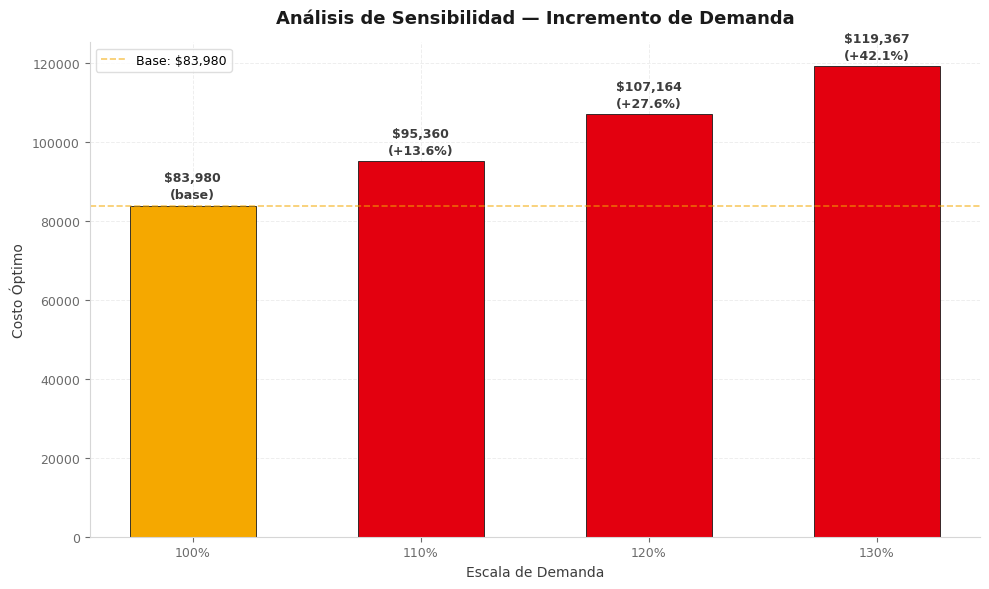

Guardado: sensitivity_analysis.png


In [19]:
def plot_sensitivity(df):
    costs  = df['Costo óptimo'].values
    labels = df['Escala demanda'].values
    deltas = df['Δ costo vs base (%)'].values
    bar_colors = [TERNIUM['orange']] + [TERNIUM['red']] * (len(costs) - 1)

    fig, ax = plt.subplots(figsize=(10, 6))
    _base_style(ax, fig)
    bars = ax.bar(labels, costs, color=bar_colors, edgecolor=TERNIUM['black'],
                  linewidth=0.6, zorder=2, width=0.55)

    for bar, cost, delta in zip(bars, costs, deltas):
        label = f'${cost:,.0f}\n(+{delta:.1f}%)' if delta > 0 else f'${cost:,.0f}\n(base)'
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(costs) * 0.015,
                label, ha='center', color=TERNIUM['dark_gray'], fontsize=9,
                fontweight='bold', linespacing=1.4)

    ax.axhline(y=costs[0], color=TERNIUM['orange'], linestyle='--',
               linewidth=1.2, alpha=0.6, label=f'Base: ${costs[0]:,.0f}')
    ax.set_title('Análisis de Sensibilidad — Incremento de Demanda',
                 color=TERNIUM['black'], fontsize=13, fontweight='bold', pad=14)
    ax.set_xlabel('Escala de Demanda', fontsize=10)
    ax.set_ylabel('Costo Óptimo', fontsize=10)
    ax.legend(fontsize=9, edgecolor=TERNIUM['light_gray'])
    plt.tight_layout()
    plt.savefig('sensitivity_analysis.png', dpi=150, bbox_inches='tight', facecolor=TERNIUM['bg'])
    plt.show()
    print('Guardado: sensitivity_analysis.png')

plot_sensitivity(df_sensitivity)

## Conclusiones

- **Estado:** El solver OR-Tools encuentra la solución **ÓPTIMA** para el escenario base.
- **Costo base:** Minimizado respetando todas las restricciones de capacidad y demanda.
- **Sensibilidad al +20% demanda:** El costo escala aproximadamente +27.6% — señal de que la red opera cerca de su capacidad máxima.
- **Reproducibilidad:** Todos los resultados son reproducibles con `seed=42`.
- **Recomendación:** Si la demanda crece sostenidamente >25%, se recomienda evaluar expansión de capacidad en los almacenes con mayor utilización.

---
> **Archivos generados:** `flow_map.png`, `cost_distribution.png`, `sensitivity_analysis.png`